In [89]:
import os
from asyncio import Semaphore

from dotenv import load_dotenv
from pandas import DataFrame
from pydantic import BaseModel
import asyncio
import pandas as pd
from pathlib import Path
from typing import Literal
import random


# load env vars
load_dotenv()

True

# Load Data


## Civility dataset

In [90]:
def load_civility_crcs(xlsx_path: str | Path, message_column: str = "message") -> pd.DataFrame:
    xlsx_path = Path(xlsx_path)

    df = pd.read_excel(xlsx_path)

    if message_column not in df.columns:
        raise ValueError(
            f"Column '{message_column}' not found. Available columns: {list(df.columns)}"
        )

    messages_df = (
        df
        .dropna()
        .astype({message_column: str})
        .assign(**{message_column: lambda d: d[message_column].str.strip()})
    )
    messages_df = messages_df[messages_df[message_column] != ""].reset_index(drop=True)
    return messages_df

civility_crcs_test_set = load_civility_crcs(
    "dataset/civility/Analysis_on_ToxiCR/test_ToxiCR.xlsx",
    message_column="message"
)
print(f'Training set for civility: {civility_crcs_test_set.shape[0]} rows')

civility_crcs_test_set.head()

civility_crcs_train_set = load_civility_crcs(
    "dataset/civility/Analysis_on_ToxiCR/test_mydata.xlsx",
    message_column="message"
)
print(f'Test set for civility: {civility_crcs_train_set.shape[0]} rows')

civility_crcs_train_set.head()

Training set for civility: 230 rows
Test set for civility: 4700 rows


,message,is_toxic
0,Whoever wrote this code must have been asleep!,1
1,Is this a joke? Fix this piece of crap.,1
2,I can't believe someone thought this was accep...,1
3,This is a disaster waiting to happen. Fix it A...,1
4,Did a monkey randomly type this code?,1


## Usefulness dataset

In [91]:
train_csv_path = Path("dataset/usefulness/training_messages_usefulness.csv")
val_csv_path = Path("dataset/usefulness/validation_messages_usefulness.csv")

usefulness_train_df = pd.read_csv(train_csv_path)
usefulness_val_df = pd.read_csv(val_csv_path)

print(f"Training rows: {usefulness_train_df.shape[0]}")

print("\nTraining label counts:")
print(usefulness_train_df["is_useful"].value_counts(dropna=False).sort_index())

usefulness_train_df.head()

print(f"Validation rows: {usefulness_val_df.shape[0]}")

print("\nValidation label counts:")
print(usefulness_val_df["is_useful"].value_counts(dropna=False).sort_index())

usefulness_val_df.head()

Training rows: 2231

Training label counts:
is_useful
0     995
1    1236
Name: count, dtype: int64
Validation rows: 732

Validation label counts:
is_useful
0    208
1    524
Name: count, dtype: int64


,message,is_useful,source_file,source_line
0,What the heck was the point of all the `JSONVi...,0,CS-corpus-100.txt,1
1,not that it matter much but we could remove th...,1,CS-corpus-100.txt,2
2,You can see how we check for running jobs in t...,1,CS-corpus-100.txt,3
3,"Instead of double negative, I think it's easie...",1,CS-corpus-100.txt,4
4,I believe `COMPANY_NAME` should be used here. ...,1,CS-corpus-100.txt,5


# Metric Definitions


In [92]:
class MetricEvaluation(BaseModel):
    specific_metric_name: str
    evaluation_reasoning: str
    direct_quote_evidence: str | None
    failed_metric_check: bool

class CodeReviewActionPlan(BaseModel):
    deficiency_synthesis: str
    constructive_recommendations: list[str]
    revision_strategy: str
    suggested_revision: str

class Metric(BaseModel):
    evaluation_category: str
    specific_metric_name: str
    description: str

# Metrics generated by Gemini Pro with the prompt:
# Synthesize the insights from this paper into a prompt for a code review comment reviewer. Pull out specific aspects and heuristics this paper notes as being important for a good code review comment.

# civility
# Rahman, Md Shamimur, Zadia Codabux, and Chanchal K. Roy. "Do words have power? understanding and fostering civility in code review discussion." Proceedings of the ACM on Software Engineering 1.FSE (2024): 1632-1655.
civility_metrics = [
    Metric(
        evaluation_category="Civility",
        specific_metric_name="Explicit Attacks",
        description="Direct insults, name-calling, or unprofessional hostility."
    ),
    Metric(
        evaluation_category="Civility",
        specific_metric_name="Tonal Behaviors",
        description="Indicators of arrogance, impatience, entitlement, or frustration."
    ),
    Metric(
        evaluation_category="Civility",
        specific_metric_name="Nuanced Incivility",
        description="Subtle mockery, provocation, or disrespectful references to identity (gender, race, etc.)."
    ),
    Metric(
        evaluation_category="Civility",
        specific_metric_name="Competence Questioning",
        description='Derogatory remarks regarding basic skills or labeling work as subpar.'
    )
]

# Yang, Lanxin, et al. "Evacrc: Evaluating code review comments." Proceedings of the 31st ACM Joint European Software Engineering Conference and Symposium on the Foundations of Software Engineering. 2023.
quality_metrics = [
    Metric(
        evaluation_category="Quality",
        specific_metric_name="Emotion (Tone)",
        description="Assess the tone of the comment. Ensure it is respectful, constructive, and positive or neutral. Flag any negative, condescending, or aggressive language."
    ),
    Metric(
        evaluation_category="Quality",
        specific_metric_name="Question (Inquiry)",
        description="Evaluate if the comment effectively uses questions. Good comments often ask clarifying questions to understand the author's original intent or reasoning rather than making immediate assumptions."
    ),
    Metric(
        evaluation_category="Quality",
        specific_metric_name="Evaluation (Assessment)",
        description="Determine if the comment clearly identifies and explains a specific issue in the code (e.g., functional defects, security flaws, readability issues, or coding standard violations). Does it clearly state why something is an issue?"
    ),
    Metric(
        evaluation_category="Quality",
        specific_metric_name="Suggestion (Actionability)",
        description="Check whether the comment provides a concrete, actionable solution, alternative approach, or specific guidance to help the author fix the identified problem."
    )
]

# Rahman, Mohammad Masudur, Chanchal K. Roy, and Raula G. Kula. "Predicting usefulness of code review comments using textual features and developer experience." 2017 IEEE/ACM 14th International Conference on Mining Software Repositories (MSR). IEEE, 2017.
usefulness_metrics = [
    Metric(
        evaluation_category="Usefulness",
        specific_metric_name="Actionability",
        description="Does the comment warrant a clear action or suggest a specific code change within the immediate vicinity (1-10 lines) of the code? Evaluate if it moves beyond merely asking open-ended questions for clarification."
    ),
    Metric(
        evaluation_category="Usefulness",
        specific_metric_name="Relevant Code Elements",
        description="Does the comment explicitly reference salient code artifacts, such as specific program entity names, methods, or variables present in the patch?"
    ),
    Metric(
        evaluation_category="Usefulness",
        specific_metric_name="Conceptual Similarity",
        description="Does the feedback share vocabulary and conceptually align with the specific lines of code being changed?"
    ),
    Metric(
        evaluation_category="Usefulness",
        specific_metric_name="Conciseness",
        description="Is the comment direct and focused? Evaluate whether it minimizes unnecessary filler words to deliver the feedback efficiently."
    ),
    Metric(
        evaluation_category="Usefulness",
        specific_metric_name="Directness",
        description="Does the comment rely too heavily on questions rather than providing clear, actionable statements? (Comments that simply ask for clarification without suggesting a path forward are statistically less useful)."
    )
]

# Chen, Junkai, et al. "Understanding practitioners’ expectations on clear code review comments." Proceedings of the ACM on Software Engineering 2.ISSTA (2025): 1257-1279.
clarity_metrics = [
    Metric(
        evaluation_category="Clarity",
        specific_metric_name="Relevance",
        description="Does the code review comment directly address the specific code change being reviewed? Ensure the feedback is highly contextualized to the lines of code, architecture, or logic modified in the pull request, avoiding off-topic remarks."
    ),
    Metric(
        evaluation_category="Clarity",
        specific_metric_name="Informativeness",
        description="Does the comment provide sufficient information for the author to understand the issue and know how to fix it? If the comment is rejecting a change or pointing out a flaw, does it at least include a suggestion for an alternative approach? Does the comment include necessary pointers, references to documentation, or links to existing discussions to support the feedback?"
    ),
    Metric(
        evaluation_category="Clarity",
        specific_metric_name="Expression",
        description="Is the comment written in a way that is easily digestible and positively received? Check that the language is clear, readable, easy to understand, and maintains a friendly, constructive tone. Avoid overly critical or ambiguous phrasing."
    )
]

dimensions = [ civility_metrics, quality_metrics , usefulness_metrics, clarity_metrics ]

# Process metrics into a string so the "rubric" can be put into prompts
heuristics_parts = []
for dimension in dimensions:
    if not dimension:
        continue

    category_name = dimension[0].evaluation_category.upper()
    heuristics_parts.append(f"{category_name}:")

    for metric in dimension:
        heuristics_parts.append(f"  - {metric.specific_metric_name}: {metric.description}")

    heuristics_parts.append("") # Add a blank line between categories for readability

dynamic_heuristics_string = "\n".join(heuristics_parts)


# LLM Inference

In [93]:
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.agents import AssistantAgent

model_client = OpenAIChatCompletionClient(
    model="gpt-4o",
    api_key= os.getenv("OPENAI_API_KEY")
)

example_crc = "Why are you continuing to use this depreciated method when we have discussed the alternatives. You need to come ask me questions if you are confused again, this is a waste of my time and company money."

## Compound AI System (Eval Metrics, Summarize Categories, Final Generation)

In [94]:
async def eval_metric(metric: Metric, crc_text: str):
    evaluator_agent = AssistantAgent(
        name="metric_evaluator",
        model_client=model_client,
        system_message="You are an expert code review evaluator. Assess the provided comment against the specific metric and output strictly matching the requested JSON schema.",
        output_content_type =MetricEvaluation
    )

    task_prompt = f"""
        Evaluate this code review comment:
        "{crc_text}"

        Category: {metric.evaluation_category}
        Metric: {metric.specific_metric_name}
        Definition: {metric.description}
        """

    result = await evaluator_agent.run(task=task_prompt)

    response_text = result.messages[-1].content
    evaluation = MetricEvaluation.model_validate(response_text)
    return evaluation


async def synthesize_deficiencies(evaluation_category, failed_evals: list[MetricEvaluation], crc_text: str) -> str:
    if not failed_evals:
        return "No deficiencies found."

    metrics_context = "\n".join(
        [f"- [{evaluation_category} | {eval.specific_metric_name}]: {eval.evaluation_reasoning} (Evidence: '{eval.direct_quote_evidence}')"
         for eval in failed_evals]
    )

    synthesis_prompt = f"""
    You are a strict code review auditor. Your sole objective is to synthesize a list of failed evaluation metrics into a succinct, focused summary of a code review comment's deficiencies.

    # Constraints
    - DIAGNOSE ONLY: You must only describe what is wrong with the comment.
    - NO SOLUTIONS: Do absolutely NOT suggest solutions, improvements, or alternative phrasing.
    - NO REWRITES: Do NOT attempt to rewrite the comment into a better version.
    - Be concise, analytical, and objective. Group related failures together.

    # Context
    Original Code Review Comment:
    "{crc_text}"

    Failed Metrics & Evidence:
    {metrics_context}
    """

    synthesis_agent = AssistantAgent(name="deficiency_summarizer", model_client=model_client)
    result = await synthesis_agent.run(task=synthesis_prompt)

    return result.messages[-1].content

async def generate_recommendations(deficiencies_summary: list[str], crc_text: str) -> CodeReviewActionPlan | None:
    if deficiencies_summary == "No deficiencies found.":
        return None

    summary_pretty = [f"{n}. {deficiency}" for n, deficiency in enumerate(deficiencies_summary)]
    deficiencies_text = "\n".join(summary_pretty)

    recommendation_prompt = f"""
    You are a Senior Staff Engineer mentoring a team member on effective code review communication. Your goal is to help them improve a poorly written code review comment based on a provided diagnostic summary.

    # Constraints
    - FOCUS ON ACTION: Provide 2-3 specific, actionable recommendations on how to fix the identified issues.
    - BE CONSTRUCTIVE: Maintain an encouraging and professional tone.
    - PROVIDE AN EXAMPLE: Conclude with a single, highly effective rewritten version of the original comment that resolves all deficiencies.

    # Context
    Original Code Review Comment:
    "{crc_text}"

    Identified Deficiencies:
    "{deficiencies_text}"
    """

    mentor_agent = AssistantAgent(name="recommendation_mentor", model_client=model_client, output_content_type=CodeReviewActionPlan)
    result = await mentor_agent.run(task=recommendation_prompt)

    plan = CodeReviewActionPlan.model_validate(result.messages[-1].content)
    return plan


async def process_dimension(dimension, crc_example):
    eval_tasks = [eval_metric(metric, crc_example) for metric in dimension]
    evaluations = await asyncio.gather(*eval_tasks)

    failed_evaluations = [e for e in evaluations if e.failed_metric_check]

    if not failed_evaluations:
        print(f"No deficiencies found in dimension {dimension[0].evaluation_category}")
        return None

    print(f"{len(failed_evaluations)} / {len(dimension)} issues detected in {dimension[0].evaluation_category}")

    synthesis = await synthesize_deficiencies(
        dimension[0].evaluation_category,
        failed_evaluations,
        crc_example
    )

    print(f"\n{dimension[0].evaluation_category} Summary:--------------------------------------\n{synthesis}")
    return synthesis

# Run the agent and stream the messages to the console.
async def suggest_rewrite_cais(given_crc) -> CodeReviewActionPlan | None:
    dimension_tasks = [process_dimension(dim, given_crc) for dim in dimensions]
    summaries = await asyncio.gather(*dimension_tasks)

    failed_category_summaries = [s for s in summaries if s is not None]

    if failed_category_summaries:
        print("\n\nGenerating suggestion-------------------------------------")
        suggestion = await generate_recommendations(failed_category_summaries, given_crc)
        return suggestion
    else:
        print("\n\nComment passed all checks.")
        return None


# cais_change_plan = await suggest_rewrite(example_crc)
# print(cais_change_plan)


## Single-shot baseline

In [95]:

# Single Shot Baseline
async def suggest_rewrite_monolithic(crc_text: str) -> CodeReviewActionPlan | None:
    mega_prompt = f"""
    You are an expert Senior Staff Engineer mentoring a team member on effective code review communication.
    Your task is to evaluate a poorly written code review comment against a strict set of academic heuristics,
    diagnose its flaws, and provide a highly effective rewrite.

    # Evaluation Heuristics
    {dynamic_heuristics_string}

    # Task Requirements
    1. Analyze the original comment against the Evaluation Heuristics.
    2. Synthesize the specific deficiencies.
    3. Provide 2-3 actionable recommendations to fix the communication issues.
    4. Outline your strategy for rewriting the comment.
    5. Provide the final suggested revision.
    """

    baseline_agent = AssistantAgent(
        name="baseline_mentor_agent",
        model_client=model_client,
        system_message=mega_prompt,
        output_content_type=CodeReviewActionPlan
    )

    user_task = f"""
        Please evaluate and rewrite the following code review comment:
        "{crc_text}"
        """

    result = await baseline_agent.run(task=user_task)

    action_plan = CodeReviewActionPlan.model_validate(result.messages[-1].content)
    return action_plan

# monolithic_change_plan = await run_baseline_agent(example_crc)
# print(monolithic_change_plan)

## Comparison

In [96]:
class PairwiseEvaluation(BaseModel):
    chain_of_reasoning: str
    winner: Literal["Comment A", "Comment B", "Tie"]

async def evaluate_suggested_revisions(given_crc : str, plan_a: CodeReviewActionPlan, plan_b : CodeReviewActionPlan) -> PairwiseEvaluation:
    judge_system_instruction = f"""
    You are an expert engineering manager evaluating two code review comments to determine which is better.
    Compare Comment A and Comment B based on the following criteria:
    {dynamic_heuristics_string}

    First, write a step-by-step comparison in the chain_of_reasoning field.
    Then, declare the winner that best adheres to the criteria, or declare a Tie if they are functionally equivalent.

    # Constraints for judging:
    - Do not penalize a comment for being concise. Directness is often preferred over unnecessary filler.
    - Focus heavily on whether the revision is actionable and specific to the code context.
    - Output strictly matching the requested JSON schema.
    """

    judge_agent = AssistantAgent(
        name="pairwise_judge_agent",
        model_client=model_client,
        system_message=judge_system_instruction,
        output_content_type=PairwiseEvaluation
    )

    # 4. Define the User Task
    user_task = f"""
    Original Code Review Comment (for context):
    "{given_crc}"

    Revision A:
    "{plan_a.suggested_revision}"

    Revision B:
    "{plan_b.suggested_revision}"

    Compare Revision A and Revision B against the heuristics. Provide your step-by-step reasoning, then declare the winner.
    """

    print("Evaluating pairwise comparison...")
    result = await judge_agent.run(task=user_task)

    evaluation = PairwiseEvaluation.model_validate(result.messages[-1].content)

    return evaluation

# pairwise_eval = await evaluate_suggested_revisions(example_crc, cais_change_plan, monolithic_change_plan)
# print(pairwise_eval)

# pairwise_eval_reversed = await evaluate_suggested_revisions(example_crc, monolithic_change_plan, cais_change_plan)
# print(pairwise_eval_reversed)


# Test Harness

In [105]:
class Result(BaseModel):
    given_crc: str
    cais_plan: CodeReviewActionPlan
    monolithic_plan: CodeReviewActionPlan
    evaluation: PairwiseEvaluation
    cais_plan_won: bool
    monolithic_plan_won: bool

async def process_trial(given_crc: str, sem : Semaphore) -> Result:

    print(f"Evaluating CRC: {given_crc}")
    async with sem:
        monolithic_plan, cais_plan = await asyncio.gather(
            suggest_rewrite_monolithic(given_crc),
            suggest_rewrite_cais(given_crc)
        )

        if not monolithic_plan or not cais_plan:
            raise ValueError("Expected two plans")

        print(f"Monolithic: {monolithic_plan.suggested_revision}")
        print(f"Cais: {cais_plan.suggested_revision}")

        # Want to randomize the ordering to avoid LLM precedent effects
        is_cais_a = random.choice([True, False])

        plan_a = cais_plan if is_cais_a else monolithic_plan
        plan_b = monolithic_plan if is_cais_a else cais_plan

        evaluation = await evaluate_suggested_revisions(given_crc, plan_a, plan_b)
        winner = evaluation.winner

        cais_won = False
        monolithic_won = False

        if winner == "Tie":
            cais_won = True
            monolithic_won = True
        elif winner == "Comment A":
            cais_won = is_cais_a
            monolithic_won = not is_cais_a
        elif winner == "Comment B":
            cais_won = not is_cais_a
            monolithic_won = is_cais_a

        return Result(
            given_crc=given_crc,
            cais_plan=cais_plan,
            monolithic_plan=monolithic_plan,
            evaluation=evaluation,
            cais_plan_won=cais_won,
            monolithic_plan_won=monolithic_won
        )


async def test_harness(crc_df : DataFrame, n = 5) -> list[Result]:
    messages = crc_df['message'].head(n).tolist()

    # Run into rate limiting if I have more than 1, so this could be more parallel, but not with the current api
    sem = asyncio.Semaphore(1)

    tasks = [process_trial(msg, sem) for msg in messages]
    results = await asyncio.gather(*tasks)

    return results

test_results = await test_harness(usefulness_val_df, 25)

Evaluating CRC: What the heck was the point of all the `JSONView` handlers in the test code? We don't run `dev_appserver` as part of our test suite so I am re4ally confused what the purpose of these was. Although maybe it is best left to my imagination...
Evaluating CRC: not that it matter much but we could remove the indentation with ```if e.content and ....```
Evaluating CRC: You can see how we check for running jobs in the `run` method on our `ScrapyJobStarter` class. app.domain.scrapy_management.ScrapyJobStarter#run
Evaluating CRC: Instead of double negative, I think it's easier to read if it's `if u'\u00b7' not in address_container or u',' in address_container`
Evaluating CRC: I believe `COMPANY_NAME` should be used here. ("cname" instead of "name") -- check out app.domain.profile.Profile to see where it's used
Evaluating CRC: I think you can remove the `?` from the url.
Evaluating CRC: Personally I'd like to see this `60` as a constant at the top. I think it just makes it easier 

Total Evaluations: 25
CAIS Win Rate:       56.0% (14)
Monolithic Win Rate: 44.0% (11)
Tie Rate:            0.0% (0)


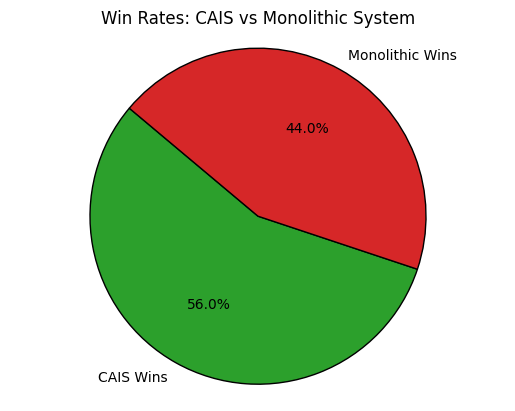


Pie chart saved as 'win_rates.png'


In [106]:
import matplotlib.pyplot as plt
from typing import List

def analyze_results(results: List[Result]):
    total = len(results)
    if total == 0:
        print("No results to analyze.")
        return

    cais_wins = sum(1 for r in results if r.cais_plan_won and not r.monolithic_plan_won)
    mono_wins = sum(1 for r in results if r.monolithic_plan_won and not r.cais_plan_won)
    ties = sum(1 for r in results if r.cais_plan_won and r.monolithic_plan_won)

    cais_pct = (cais_wins / total) * 100
    mono_pct = (mono_wins / total) * 100
    tie_pct = (ties / total) * 100

    print(f"Total Evaluations: {total}")
    print(f"CAIS Win Rate:       {cais_pct:.1f}% ({cais_wins})")
    print(f"Monolithic Win Rate: {mono_pct:.1f}% ({mono_wins})")
    print(f"Tie Rate:            {tie_pct:.1f}% ({ties})")

    labels = ['CAIS Wins', 'Monolithic Wins', 'Ties']
    sizes = [cais_wins, mono_wins, ties]
    colors = ['#2ca02c', '#d62728', '#ff7f0e']

    filtered_labels = [l for l, s in zip(labels, sizes) if s > 0]
    filtered_sizes = [s for s in sizes if s > 0]
    filtered_colors = [c for c, s in zip(colors, sizes) if s > 0]

    plt.pie(
        filtered_sizes,
        labels=filtered_labels,
        colors=filtered_colors,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'black'}
    )
    plt.title('Win Rates: CAIS vs Monolithic System')
    plt.axis('equal')

    plt.savefig("win_rates.png")
    plt.show()
    print("\nPie chart saved as 'win_rates.png'")

analyze_results(test_results)